In [1]:
import importlib.resources
import sys
import re
import os
import json
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

font1 = {"weight": "bold", "size": 18}

## Read the determinstic PT results

In [2]:
# define the path
root_path = os.path.join(os.getcwd(), "..", "Data", "fossil_results_PT_determinstic_RT_LMP")

# read generator parameters and names
gen_path = gen_path = os.path.join(os.getcwd(), "..", "Data", "gen_dict.json")

with open(gen_path, 'rb') as f:
    gen_dict = json.load(f)

# read the generator names
gen_names = list(gen_dict["fossil"].keys())

In [3]:
# check the result of one generator.
gen_csv_path = os.path.join(root_path, "gen_" + gen_names[0] + "_result.csv")
df_gen = pd.read_csv(gen_csv_path)
print(gen_names[0])
df_gen.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yilu/Documents/GitHub/RTS-GMLC-PT/Notebook/../Data/fossil_results_PT_determinstic_RT_LMP/gen_101_CT_1_result.csv'

In [ ]:
# get column_info
def get_col_ts_info(df, col_name):
    return df[col_name]

def summarize_gen_pt_result(df, gen_name):
    
    # read and sum the data from the dataframe
    tot_dispatch = get_col_ts_info(df_gen, "power_to_grid").sum()
    tot_elec_rev = get_col_ts_info(df_gen, "elec_revenue").sum()
    tot_op_cost = get_col_ts_info(df_gen, "total_hourly_cost").sum()
    tot_startup_cost = get_col_ts_info(df_gen, "hourly_startup_cost").sum()
    tot_profit = get_col_ts_info(df_gen, "net_hourly_cash_inflow").sum()
    num_startup = get_col_ts_info(df_gen, f"gen_{gen_name}.startup").sum()
    
    # summarize the results in a dictionary
    sum_dict = {"tot_dispatch": [tot_dispatch],
                "tot_elec_rev": [tot_elec_rev],
               "tot_op_cost": [tot_op_cost],
               "tot_startup_cost": [tot_startup_cost],
               "tot_profit": [tot_profit],
               "num_startup": [int(num_startup)],}
    
    df_summarize = pd.DataFrame(sum_dict)
    df_summarize.index = [gen_name]
    
    return df_summarize

summarize_gen_pt_result(df_gen, gen_names[0])

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,11836.0,4.591634e+06,1.397912e+06,7296.327,3.186425e+06,141


In [ ]:
# loop over all fossil generators and save results in a dataframe
df_all_gen_summarize_PT = pd.DataFrame()

for name in gen_names:
    gen_csv_path = os.path.join(root_path, "gen_" + name + "_result.csv")
    df_gen = pd.read_csv(gen_csv_path)
    df_summarize = summarize_gen_pt_result(df_gen, name)
    df_all_gen_summarize_PT = pd.concat([df_all_gen_summarize_PT, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PT

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,11836.0,4.591634e+06,1.397912e+06,7.296327e+03,3.186425e+06,141
101_CT_2,11836.0,4.591634e+06,1.397912e+06,7.296327e+03,3.186425e+06,141
101_STEAM_3,454066.0,2.830628e+07,9.603489e+06,5.670368e+05,1.813575e+07,54
101_STEAM_4,454066.0,2.830628e+07,9.603489e+06,5.670368e+05,1.813575e+07,54
102_CT_1,11864.0,4.593464e+06,1.456492e+06,6.985845e+03,3.129986e+06,135
...,...,...,...,...,...,...
321_CC_1,621945.0,1.005573e+08,1.693090e+07,3.197322e+06,8.042907e+07,114
322_CT_5,57343.0,1.449060e+07,2.088746e+06,6.968238e+05,1.170503e+07,123
322_CT_6,57343.0,1.449060e+07,2.088746e+06,6.968238e+05,1.170503e+07,123
323_CC_1,529830.0,9.954265e+07,1.515941e+07,3.533882e+06,8.084936e+07,126


## Read the Prescient Results

In [ ]:
# read the Prescient results
dispatch_path = "Generator_Dispatch.csv"
lmp_path = "Bus_LMP.csv"

df_lmp = pd.read_csv(lmp_path)
df_dispatch = pd.read_csv(dispatch_path)

# print(df_lmp.columns)
# print(df_dispatch.columns)

### Calculate the total dispatch

In [ ]:
# calculate the total dispatch
gen_names = list(gen_dict["fossil"].keys())
dispatch_result = {}

for name in gen_names:
    # calculate annual DA/RT dispatch
    dispatch_result[name] = {}
    dispatch_result[name]["tot_Dispatch_DA"] = df_dispatch[name+"_Dispatch DA"].sum()
    dispatch_result[name]["tot_Dispatch"] = df_dispatch[name+"_Dispatch"].sum()

# save it into a dataframe
df_pcm = pd.DataFrame.from_dict(dispatch_result, orient='index')

df_pcm.head()

,tot_Dispatch_DA,tot_Dispatch
101_CT_1,3704.000000,3826.552000
101_CT_2,3728.000000,3802.000000
101_STEAM_3,634588.239485,580194.618309
101_STEAM_4,649308.525443,590024.388929
102_CT_1,976.000000,976.000000


## Calculate the operation costs

In [ ]:
def sign(x):
    if x > 0.1:
        y = 1
    else:
        y = 0
    return y

# example to calculate the 101_STEAM_3
cost = 0

for i in df_dispatch["101_STEAM_3_Dispatch"]:
    cost += i*16.466 + 331.44*sign(i)

# startup costs
# here is just a rough estimation, which assumes all cold startup.
cost = cost + 6*gen_dict['fossil']['101_STEAM_3']['fuel_p']*gen_dict['fossil']['101_STEAM_3']['start_heat_cold']

# whether it is clearer by DA LMP or RT LMP?
rev = df_dispatch["101_STEAM_3_Dispatch"] * df_lmp["Abel_LMP"]

# calculate total revenue
rev.sum() - cost

16607641.840021359

In [ ]:
gen_dict['fossil']['101_STEAM_3']

{'name': '101_STEAM_3',
 'bus_name': 'Abel',
 'gen_type': 'STEAM',
 'max_p': 76.0,
 'min_p': 30,
 'ramp': 120.0,
 'fuel_p': 2.11399,
 'min_down_time': 4,
 'min_up_time': 8,
 'start_up_time_hot': 3,
 'start_up_time_warm': 10,
 'start_up_time_cold': 12,
 'start_heat_hot': 3379.4,
 'start_heat_warm': 4861.4,
 'start_heat_cold': 5284.8,
 'cost_curve': {'slope': 16.465999999999998, 'intercept': 331.4380855711627}}

## Summarize the LMP infomation from PCM

In [ ]:
LMP_result = {}

for name in gen_names:
    bus_name = gen_dict["fossil"][name]["bus_name"]
    LMP_result[bus_name] = {}
    LMP_result[bus_name][f"LMP_DA_mean"] = df_lmp[f"{bus_name}_LMP DA"].mean()
    LMP_result[bus_name][f"LMP_DA_median"] = df_lmp[f"{bus_name}_LMP DA"].median()
    LMP_result[bus_name][f"LMP_DA_min"] = df_lmp[f"{bus_name}_LMP DA"].min()
    LMP_result[bus_name][f"LMP_DA_max"] = df_lmp[f"{bus_name}_LMP DA"].max()
    LMP_result[bus_name][f"LMP_mean"] = df_lmp[f"{bus_name}_LMP"].mean()
    LMP_result[bus_name][f"LMP_median"] = df_lmp[f"{bus_name}_LMP"].median()
    LMP_result[bus_name][f"LMP_min"] = df_lmp[f"{bus_name}_LMP"].min()
    LMP_result[bus_name][f"LMP_max"] = df_lmp[f"{bus_name}_LMP"].max()
    
# LMP_result

## Calculate the number of startups in PCM

In [ ]:
def calculate_PCM_startups(gen_name, df_dispatch):
    df_state = df_dispatch[f"{gen_name}_Unit State"]
    
    startup = 0
    shutdown = 0
    # for all the state from 1 to end, 
    # do a substraction from df_state[i] - df_state[i-1]
    
    for i in range(1, len(df_state)):
        state = int(df_state[i]) - int(df_state[i-1])
        # 0-0/1-1 unchanged, 1-0 startup, 0-1 shutdown
        if state == 0:
            continue
        elif state == 1:
            startup += 1
        elif state == -1:
            shutdown += 1
        else:
            raise ValueError(f"Wrong with the state in time step {i}.")
    
    return int(startup)

# startup, shutdown = calculate_PCM_startups(gen_name=gen_names[0], df_dispatch=df_dispatch)

## Calculate the total revenue, profit, cost

The profit from manually calculation and PCM exact solution has a small bias. 

For example, the 101_STEAM_3, total profit from manual calculation is 16607642 and from PCM exact solution is 16538621. The difference (0.42%) mainly comes from the linear approximation for the operation costs.

In [ ]:
# calculate the revenue by rt_lmp * rt_dispatch
PCM_result = {}

def summarize_gen_pcm_result(df_dispatch, df_lmp, gen_name):
    PCM_result = {}
    bus_name = gen_dict["fossil"][gen_name]["bus_name"]
    elec_rev = df_lmp[f"{bus_name}_LMP"] * df_dispatch[name+"_Dispatch"]
    PCM_result["tot_elec_rev"] = [elec_rev.sum()]
    PCM_result["tot_dispatch"] = [df_dispatch[gen_name+"_Dispatch"].sum()]
    PCM_result["tot_op_cost"] = [df_dispatch[gen_name+"_Unit Cost"].sum()]
    # attention, in Prescient, Unit Cost column includes the startup cost
    PCM_result["tot_profit"] = [elec_rev.sum() - df_dispatch[gen_name+"_Unit Cost"].sum()]
    PCM_result["num_startup"] = [calculate_PCM_startups(gen_name, df_dispatch)]
    
    df_summarize = pd.DataFrame(PCM_result)
    df_summarize.index = [gen_name]
    
    return df_summarize

In [ ]:
# loop over all fossil generators
df_all_gen_summarize_PCM = pd.DataFrame()

for name in gen_names:
    df_summarize = summarize_gen_pcm_result(df_dispatch, df_lmp, name)
    df_all_gen_summarize_PCM = pd.concat([df_all_gen_summarize_PCM, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PCM.head()

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
101_CT_1,3.292333e+05,3826.552000,5.341876e+05,-2.049543e+05,370
101_CT_2,2.779279e+05,3802.000000,5.325415e+05,-2.546136e+05,370
101_STEAM_3,2.907523e+07,580194.618309,1.253661e+07,1.653862e+07,6
101_STEAM_4,2.996781e+07,590024.388929,1.270444e+07,1.726338e+07,1
102_CT_1,4.494933e+04,976.000000,1.536101e+05,-1.086608e+05,111


## Compare PCM with PT

### Calculate the difference

In [ ]:
# We now compare the following results

# total dispatch
def calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name, item):
    """
    diff = PT_result - PCM_result
    """
    PCM_result = df_all_gen_summarize_PCM.loc[gen_name][item]
    PT_result = df_all_gen_summarize_PT.loc[gen_name][item]
    diff = PT_result - PCM_result
    
    return diff

df_diff = pd.DataFrame()

for name in gen_names:
    # PCM has fewer columns than PT
    dict_diff = {}
    for item_ in df_all_gen_summarize_PCM.columns:
        diff = calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name=name, item=item_)
        dict_diff[f"{item_}_diff"] = [diff]
    df_diff_gen = pd.DataFrame(dict_diff)
    df_diff_gen.index = [name]
    df_diff = pd.concat([df_diff, df_diff_gen], ignore_index=False)

df_diff.head()

,tot_elec_rev_diff,tot_dispatch_diff,tot_op_cost_diff,tot_profit_diff,num_startup_diff
101_CT_1,4.262401e+06,8009.448000,8.637244e+05,3.391380e+06,-229.0
101_CT_2,4.313706e+06,8034.000000,8.653705e+05,3.441039e+06,-229.0
101_STEAM_3,-7.689496e+05,-126128.618309,-2.933118e+06,1.597132e+06,48.0
101_STEAM_4,-1.661536e+06,-135958.388929,-3.100950e+06,8.723772e+05,53.0
102_CT_1,4.548515e+06,10888.000000,1.302881e+06,3.238647e+06,24.0


### Get the type of the generators

In [ ]:
# get the type of generators (CC, CT, STEAM)
CT_gen = []
CC_gen = []
STEAM_gen = []

for name in gen_names:
    gen_form = re.split(r"\_", name)[1]
#     print(gen_form)
    if gen_form == "CT":
        CT_gen.append(name)
    elif gen_form == "CC":
        CC_gen.append(name)
    elif gen_form == "STEAM":
        STEAM_gen.append(name)
    else:
        raise ValueError(f"Invalid generator form, {gen_form}.")

gen_forms = {"CC": CC_gen, "CT": CT_gen, "STEAM": STEAM_gen}

### Make Parity Plot

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

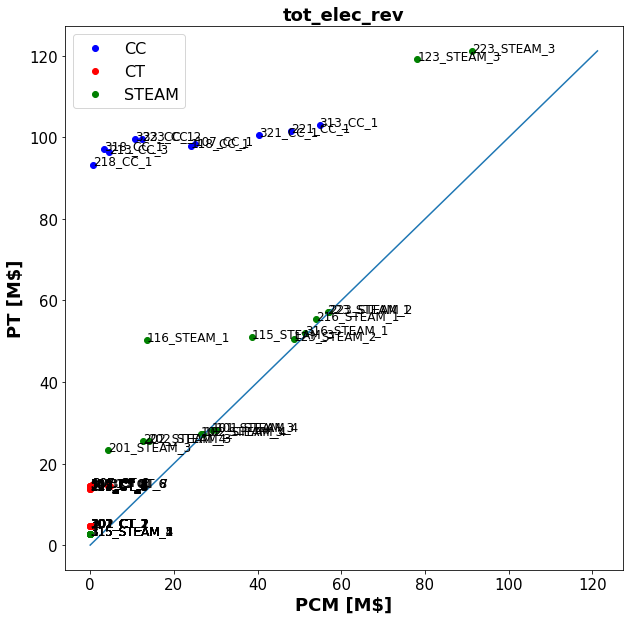

In [ ]:
def make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item, marker="dot"):
    if item in ["tot_elec_rev", "tot_op_cost", "tot_profit"]:
        factor = 1e6
        unit = "M$"
    if item == "tot_dispatch":
        factor = 1e3
        unit = "GWh"
    if item == "num_startup":
        factor =1
        unit = "#"
    color = {"CC": "b", "CT": "r", "STEAM": "g"}
    fig, ax = plt.subplots(figsize=(10, 10))
    for f in gen_forms:
        item_pt = []
        item_pcm = []
        for name in gen_forms[f]:
            y = df_all_gen_summarize_PT[df_all_gen_summarize_PT.index==name][item]/factor
            x = df_all_gen_summarize_PCM[df_all_gen_summarize_PCM.index==name][item]/factor
            item_pt.append(y)
            item_pcm.append(x)
            
            if marker == "gen_name":
                ax.text(x, y, name, fontsize=12)
        if marker == "dot":
            ax.scatter(item_pcm, item_pt, c=color[f], label=f)
        
        if marker == "both":
            for x, y, name in zip(item_pcm, item_pt, gen_forms[f]):
                ax.text(x, y, name, fontsize=12)
            ax.scatter(item_pcm, item_pt, c=color[f], label=f)
        
    # plot y = x
    minimum = min(df_all_gen_summarize_PCM[item].min()/factor, df_all_gen_summarize_PT[item].min()/factor)
    maximum = max(df_all_gen_summarize_PCM[item].max()/factor, df_all_gen_summarize_PT[item].max()/factor)
    x = np.linspace(minimum, maximum)
    ax.plot(x,x)
    ax.set_xlabel(f"PCM [{unit}]", font=font1)
    ax.set_ylabel(f"PT [{unit}]", font=font1)
    ax.set_title(f"{item}", font=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(prop={"size": 16})
    
    return

make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_elec_rev', marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

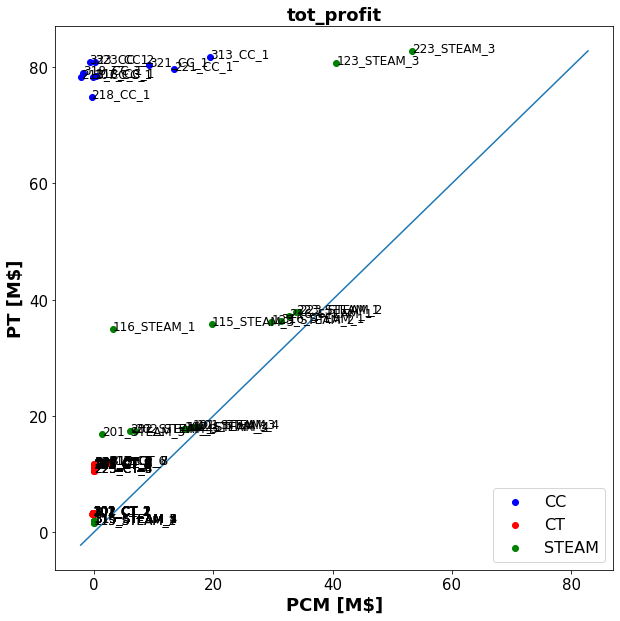

In [ ]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_profit', marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

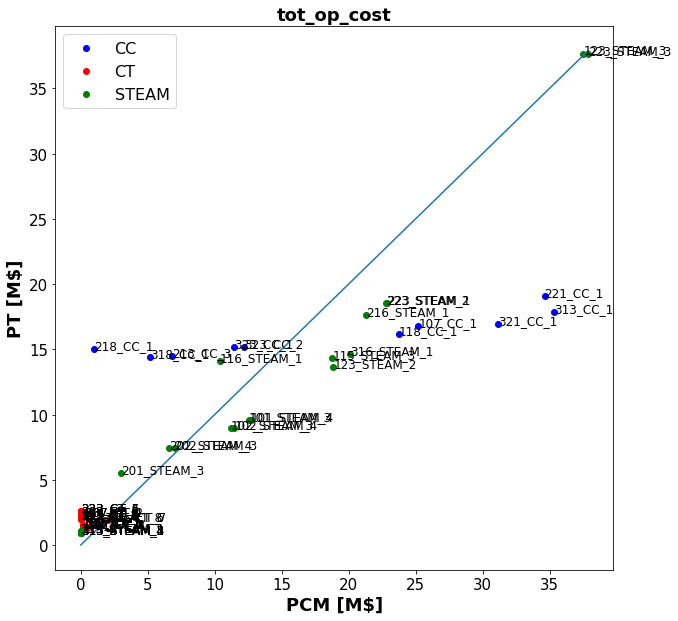

In [ ]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_op_cost", marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

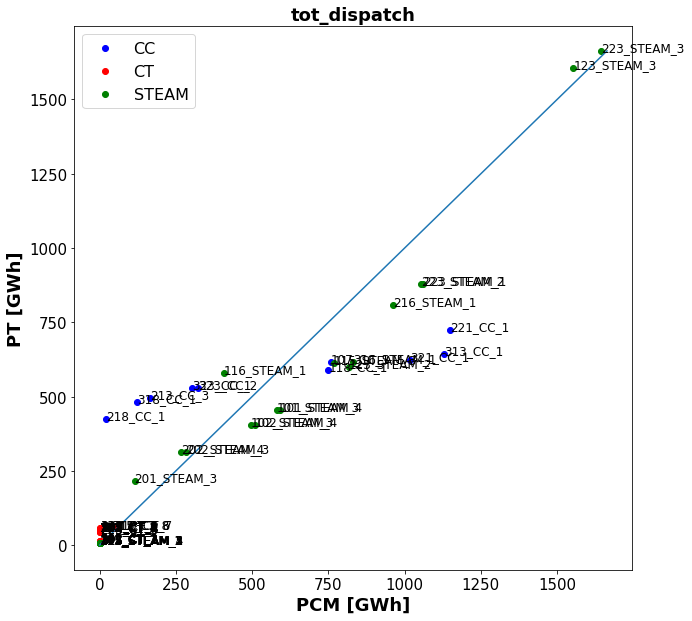

In [ ]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_dispatch", marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

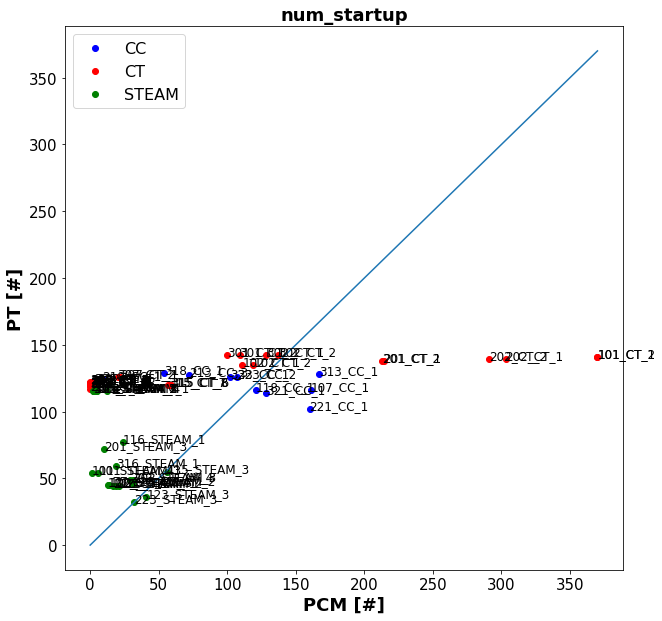

In [ ]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="num_startup", marker='both')

## Detailed generator level analysis

In [ ]:
def print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item):
    print("Gen Name    ",  f"PT_{item}    ", f"PCM_{item}    ", "Rate %")
    for name in gen_dict["fossil"].keys():
        pt_res = np.round(df_all_gen_summarize_PT.loc[name][item], 2)
        pcm_res = np.round(df_all_gen_summarize_PCM.loc[name][item], 2)
        rate = 100 * (pt_res-pcm_res)/(pcm_res + 1) # avoid divided by 0
        print(name, "    ", pt_res, "    ",  pcm_res, "    ", rate)
    return

print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item="tot_profit")

Gen Name     PT_tot_profit     PCM_tot_profit     Rate %
101_CT_1      3186425.47      -204954.32      -1654.7083940870048
101_CT_2      3186425.47      -254613.64      -1351.480079700678
101_STEAM_3      18135752.78      16538620.89      9.656982913223857
101_STEAM_4      18135752.78      17263375.57      5.053340558625147
102_CT_1      3129986.47      -108660.81      -2980.5383241513123
102_CT_2      3129986.47      -94500.03      -3412.190051051318
102_STEAM_3      17810363.62      15166857.11      17.429493246574598
102_STEAM_4      17810363.62      15559980.85      14.462631073056178
107_CC_1      78348242.81      -108748.42      -72146.07135507216
113_CT_1      11268557.14      -7302.75      -154426.8139829493
113_CT_2      11268557.14      -8720.33      -129336.51404408367
113_CT_3      11268557.14      0.0      1126855714.0
113_CT_4      11268557.14      0.0      1126855714.0
115_STEAM_1      1557226.85      -12526.59      -12532.371249577867
115_STEAM_2      1557226.85      -4

### Calculate capacity factors

In [ ]:
def calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name):
    pmax = gen_dict["fossil"][gen_name]["max_p"]
    pt_cf = df_all_gen_summarize_PT.loc[gen_name]["tot_dispatch"]/pmax/8784
    pcm_cf = df_all_gen_summarize_PCM.loc[gen_name]["tot_dispatch"]/pmax/8784
    
    return pt_cf, pcm_cf

pt_cf_dict = {}
pcm_cf_dict = {}
diff_cf_dict = {}    # (pt-pcm)/pcm
for name in gen_names:
    pt_cf, pcm_cf = calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name=name)
    pt_cf_dict[name] = pt_cf
    pcm_cf_dict[name] = pcm_cf
    diff_cf_dict[name] = (pt_cf - pcm_cf)/(pcm_cf + 1e-6)

summarize_cf_dict = {"GO":[], "SO":[], "NO":[], "NU":[], "SU":[], "GU":[]}
for key, value in diff_cf_dict.items():
    if value > 1:
        summarize_cf_dict["GO"].append(key)
    if (0.2 < value) and (value <= 1):
        summarize_cf_dict["SO"].append(key)
    if (0.0 < value) and (value <= 0.2):
        summarize_cf_dict["NO"].append(key)
    if (-0.2 < value) and (value <= 0.0):
        summarize_cf_dict["NU"].append(key)
    if (-1.0 < value) and (value <= -0.2):
        summarize_cf_dict["SU"].append(key)
    if value <= -1:
        summarize_cf_dict["GU"].append(key)
    
# summarize_cf_dict

In [ ]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["GO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     2.093     0.0674     0.0218     10.3494
101_CT_2     2.113     0.0674     0.0216     10.3494
102_CT_1     11.1537     0.0675     0.0056     10.3494
102_CT_2     10.4943     0.0675     0.0059     10.3494
113_CT_1     659.7179     0.106     0.0002     3.88722
113_CT_2     769.0373     0.106     0.0001     3.88722
113_CT_3     105965.3916     0.106     0.0     3.88722
113_CT_4     105965.3916     0.106     0.0     3.88722
115_STEAM_1     22.4042     0.0657     0.0028     10.3494
115_STEAM_2     80.9109     0.0657     0.0008     10.3494
123_CT_1     155.032     0.1066     0.0007     3.88722
123_CT_4     140.7521     0.1066     0.0008     3.88722
123_CT_5     119.0429     0.1066     0.0009     3.88722
201_CT_1     5.083     0.068     0.0112     10.3494
201_CT_2     5.2747     0.068     0.0108     10.3494
202_CT_1     3.028     0.0684     0.017     10.3494
202_CT_2     3.1163     0.0684     0.0166     10.3494
207_CT_1   

In [ ]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
116_STEAM_1     0.4243     0.4248     0.2982     2.11399
201_STEAM_3     0.8852     0.3229     0.1713     2.11399
315_CT_6     0.3618     0.1158     0.085     3.88722
315_CT_7     0.2095     0.1158     0.0957     3.88722
315_CT_8     0.5026     0.1158     0.0771     3.88722
323_CC_1     0.7474     0.1699     0.0972     3.88722
323_CC_2     0.6382     0.1699     0.1037     3.88722


In [ ]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
123_STEAM_3     0.0341     0.5224     0.5052     2.11399
202_STEAM_3     0.1059     0.4693     0.4244     2.11399
202_STEAM_4     0.1714     0.4693     0.4007     2.11399
223_STEAM_3     0.011     0.5411     0.5352     2.11399


In [ ]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
102_STEAM_3     -0.1845     0.6065     0.7438     2.11399
107_CC_1     -0.1883     0.1975     0.2433     3.88722
216_STEAM_1     -0.1608     0.593     0.7066     2.11399
223_STEAM_1     -0.1706     0.6452     0.7779     2.11399
223_STEAM_2     -0.1666     0.6452     0.7742     2.11399


In [ ]:
# check the level of under/overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_STEAM_3     -0.2174     0.6802     0.8691     2.11399
101_STEAM_4     -0.2304     0.6802     0.8838     2.11399
102_STEAM_4     -0.204     0.6065     0.762     2.11399
115_STEAM_3     -0.2023     0.4505     0.5647     2.11399
118_CC_1     -0.2131     0.1891     0.2403     3.88722
123_STEAM_2     -0.2677     0.4394     0.6     2.11399
221_CC_1     -0.3698     0.232     0.3682     3.88722
313_CC_1     -0.4302     0.2066     0.3626     3.88722
316_STEAM_1     -0.2588     0.4531     0.6112     2.11399
321_CC_1     -0.3889     0.1994     0.3264     3.88722


In [ ]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CC"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}")

Gen name     Diff rate     PT CF     PCM CF     Fuel price
107_CC_1     -0.1883     0.1975     0.2433
118_CC_1     -0.2131     0.1891     0.2403
213_CC_3     1.984     0.1591     0.0533
218_CC_1     17.9875     0.1358     0.0072
221_CC_1     -0.3698     0.232     0.3682
313_CC_1     -0.4302     0.2066     0.3626
318_CC_1     2.9862     0.155     0.0389
321_CC_1     -0.3889     0.1994     0.3264
323_CC_1     0.7474     0.1699     0.0972
323_CC_2     0.6382     0.1699     0.1037


In [ ]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CT"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     2.093     0.0674     0.0218     10.3494
101_CT_2     2.113     0.0674     0.0216     10.3494
102_CT_1     11.1537     0.0675     0.0056     10.3494
102_CT_2     10.4943     0.0675     0.0059     10.3494
113_CT_1     659.7179     0.106     0.0002     3.88722
113_CT_2     769.0373     0.106     0.0001     3.88722
113_CT_3     105965.3916     0.106     0.0     3.88722
113_CT_4     105965.3916     0.106     0.0     3.88722
123_CT_1     155.032     0.1066     0.0007     3.88722
123_CT_4     140.7521     0.1066     0.0008     3.88722
123_CT_5     119.0429     0.1066     0.0009     3.88722
201_CT_1     5.083     0.068     0.0112     10.3494
201_CT_2     5.2747     0.068     0.0108     10.3494
202_CT_1     3.028     0.0684     0.017     10.3494
202_CT_2     3.1163     0.0684     0.0166     10.3494
207_CT_1     102527.3224     0.1025     0.0     3.88722
207_CT_2     248.5602     0.1025     0.0004     3.88722
213_CT_1     38

In [ ]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["STEAM"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_STEAM_3     -0.2174     0.6802     0.8691     2.11399
101_STEAM_4     -0.2304     0.6802     0.8838     2.11399
102_STEAM_3     -0.1845     0.6065     0.7438     2.11399
102_STEAM_4     -0.204     0.6065     0.762     2.11399
115_STEAM_1     22.4042     0.0657     0.0028     10.3494
115_STEAM_2     80.9109     0.0657     0.0008     10.3494
115_STEAM_3     -0.2023     0.4505     0.5647     2.11399
116_STEAM_1     0.4243     0.4248     0.2982     2.11399
123_STEAM_2     -0.2677     0.4394     0.6     2.11399
123_STEAM_3     0.0341     0.5224     0.5052     2.11399
201_STEAM_3     0.8852     0.3229     0.1713     2.11399
202_STEAM_3     0.1059     0.4693     0.4244     2.11399
202_STEAM_4     0.1714     0.4693     0.4007     2.11399
216_STEAM_1     -0.1608     0.593     0.7066     2.11399
223_STEAM_1     -0.1706     0.6452     0.7779     2.11399
223_STEAM_2     -0.1666     0.6452     0.7742     2.11399
223_STEAM_3     0.011   

In [ ]:
# No dispatch
df_all_gen_summarize_PCM[df_all_gen_summarize_PCM["tot_elec_rev"]==0]

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
113_CT_3,0.0,0.0,0.000000,0.000000,0
113_CT_4,0.0,0.0,0.000000,0.000000,0
207_CT_1,0.0,0.0,0.000000,0.000000,0
215_CT_4,0.0,0.0,0.000000,0.000000,0
223_CT_4,0.0,0.0,0.000000,0.000000,0
223_CT_6,0.0,0.0,0.000000,0.000000,0
301_CT_3,0.0,0.0,0.000000,0.000000,0
302_CT_3,0.0,110.0,12248.047138,-12248.047138,1
302_CT_4,0.0,0.0,0.000000,0.000000,0


In [ ]:
df_all_gen_summarize_PCM.loc["322_CT_6"], df_all_gen_summarize_PT.loc["322_CT_6"]

(tot_elec_rev    15850.459823
 tot_dispatch      539.000000
 tot_op_cost     49571.656432
 tot_profit     -33721.196609
 num_startup         5.000000
 Name: 322_CT_6, dtype: float64,
 tot_dispatch        5.734300e+04
 tot_elec_rev        1.449060e+07
 tot_op_cost         2.088746e+06
 tot_startup_cost    6.968238e+05
 tot_profit          1.170503e+07
 num_startup         1.230000e+02
 Name: 322_CT_6, dtype: float64)

## Check the marginal cost of generators

In [ ]:
for name in gen_dict["fossil"].keys():
    print(name, "    ", gen_dict["fossil"][name]["fuel_p"])


101_CT_1      10.3494
101_CT_2      10.3494
101_STEAM_3      2.11399
101_STEAM_4      2.11399
102_CT_1      10.3494
102_CT_2      10.3494
102_STEAM_3      2.11399
102_STEAM_4      2.11399
107_CC_1      3.88722
113_CT_1      3.88722
113_CT_2      3.88722
113_CT_3      3.88722
113_CT_4      3.88722
115_STEAM_1      10.3494
115_STEAM_2      10.3494
115_STEAM_3      2.11399
116_STEAM_1      2.11399
118_CC_1      3.88722
123_STEAM_2      2.11399
123_STEAM_3      2.11399
123_CT_1      3.88722
123_CT_4      3.88722
123_CT_5      3.88722
201_CT_1      10.3494
201_CT_2      10.3494
201_STEAM_3      2.11399
202_CT_1      10.3494
202_CT_2      10.3494
202_STEAM_3      2.11399
202_STEAM_4      2.11399
207_CT_1      3.88722
207_CT_2      3.88722
213_CC_3      3.88722
213_CT_1      3.88722
213_CT_2      3.88722
215_CT_4      3.88722
215_CT_5      3.88722
216_STEAM_1      2.11399
218_CC_1      3.88722
221_CC_1      3.88722
223_STEAM_1      2.11399
223_STEAM_2      2.11399
223_STEAM_3      2.11399
223